In [32]:
# Menginstal library yang dibutuhkan (jika belum ada)
!pip install numpy matplotlib opencv-python

# Mengimpor (memasukkan) library ke dalam notebook kita
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab.patches import cv2_imshow # Khusus untuk menampilkan gambar di colab
import urllib.request # Untuk mendownload gambar dari internet

# Tugas Eksperimen Operasi Dasar pada Sinyal dan Citra
**Nama:** Abdullah Tsaqif Cakrawibowo

**NIM:** 452024611036

**Kelas:** TI A1

**Mata Kuliah:** Pengolahan Sinyal Digital

## Pendahuluan Singkat

Pengolahan Sinyal Digital (PSD) merupakan salah satu pilar teknologi modern yang mendasari berbagai aplikasi komputasi saat ini, mulai dari pemrosesan komunikasi suara hingga manipulasi visual digital. Sinyal di dunia nyata dapat direpresentasikan ke dalam berbagai dimensi di dalam komputer, seperti sinyal 1-Dimensi (1D) pada data audio diskrit berbasis waktu, dan sinyal 2-Dimensi (2D) pada data citra digital yang tersusun atas matriks koordinat spasial (piksel).

Tujuan utama dari penulisan laporan ini adalah untuk membuktikan secara praktis dan analitis bahwa operasi-operasi aritmetika sederhana tersebut merupakan blok pembangun (fondasi utama) bagi konsep-konsep teknologi yang lebih besar dan kompleks dalam PSD. Di antaranya adalah pembuktian sifat homogenitas dan additivitas pada sistem linier, penerapan hukum superposisi, serta implementasi nyata pada algoritma pencampuran suara (*audio mixing*), manipulasi gambar (*image blending*), hingga teknik memperbanyak variasi data untuk kecerdasan buatan (*image augmentation*).

## Bagian A.1: Membuat Sinyal Diskrit

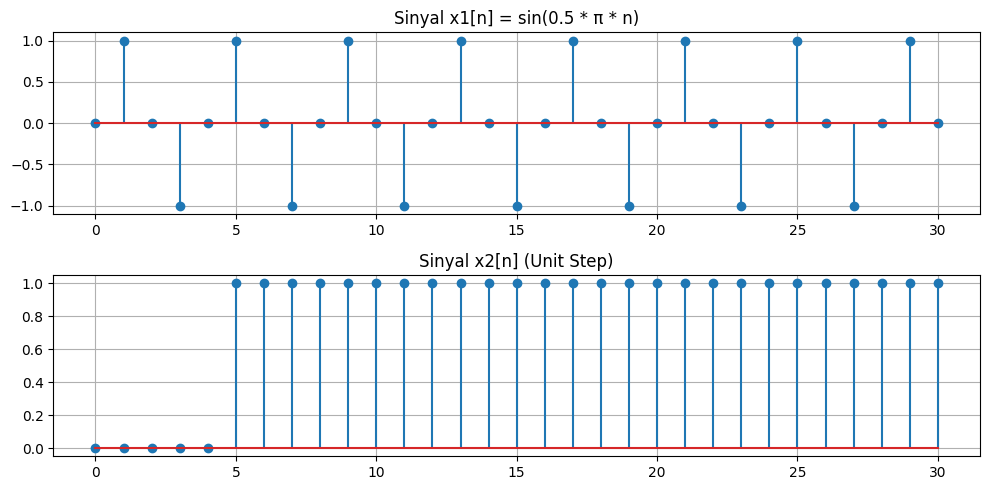

In [33]:
# Membuat rentang waktu n dari 0 sampai 30
n = np.arange(0, 31)

# Membuat Sinyal 1: x1[n] = sin(0.5 * pi * n)
x1 = np.sin(0.5 * np.pi * n)

# Membuat Sinyal 2: x2[n] (Unit Step: 0 jika n<5, 1 jika n>=5)
x2 = np.where(n < 5, 0, 1)

# Menampilkan grafik
plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.stem(n, x1)
plt.title('Sinyal x1[n] = sin(0.5 * π * n)')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.stem(n, x2)
plt.title('Sinyal x2[n] (Unit Step)')
plt.grid(True)

plt.tight_layout()
plt.show()

**Analisis Karakteristik Sinyal:**
* **Sinyal x1[n]:** Merupakan sinyal sinusoidal diskrit yang berosilasi (naik turun) antara nilai 1 dan -1 secara periodik. Sinyal ini merepresentasikan gelombang suara dasar atau nada murni.
* **Sinyal x2[n]:** Merupakan sinyal unit step yang bernilai 0 sebelum titik n=5, dan mendadak "hidup" atau bernilai 1 setelah n=5. Sinyal ini sering digunakan untuk menyimulasikan saklar atau kejadian yang tiba-tiba aktif.

## Bagian A.2: Operasi Penjumlahan Sinyal

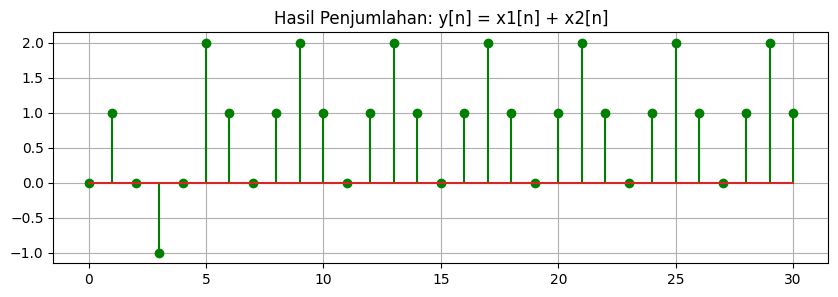

In [34]:
# Operasi Penjumlahan
y_jumlah = x1 + x2

plt.figure(figsize=(10, 3))
plt.stem(n, y_jumlah, linefmt='g-', markerfmt='go')
plt.title('Hasil Penjumlahan: y[n] = x1[n] + x2[n]')
plt.grid(True)
plt.show()

**Analisis Penjumlahan (Jawaban A.2):**
1. **Amplitudo:** Amplitudo sinyal asal (x1) bertambah 1 poin pada rentang n >= 5 karena dijumlahkan dengan x2.
2. **Bentuk:** Bentuknya masih menyerupai gelombang sinus (x1), namun posisinya tergeser ke atas (memiliki offset positif) akibat penambahan x2.
3. **Aplikasi Nyata:** Operasi penjumlahan sinyal di dunia nyata digunakan dalam proses *Audio Mixing* (menggabungkan suara vokal dan alat musik menjadi satu lagu).

## Bagian A.3: Operasi Penggeseran Sinyal

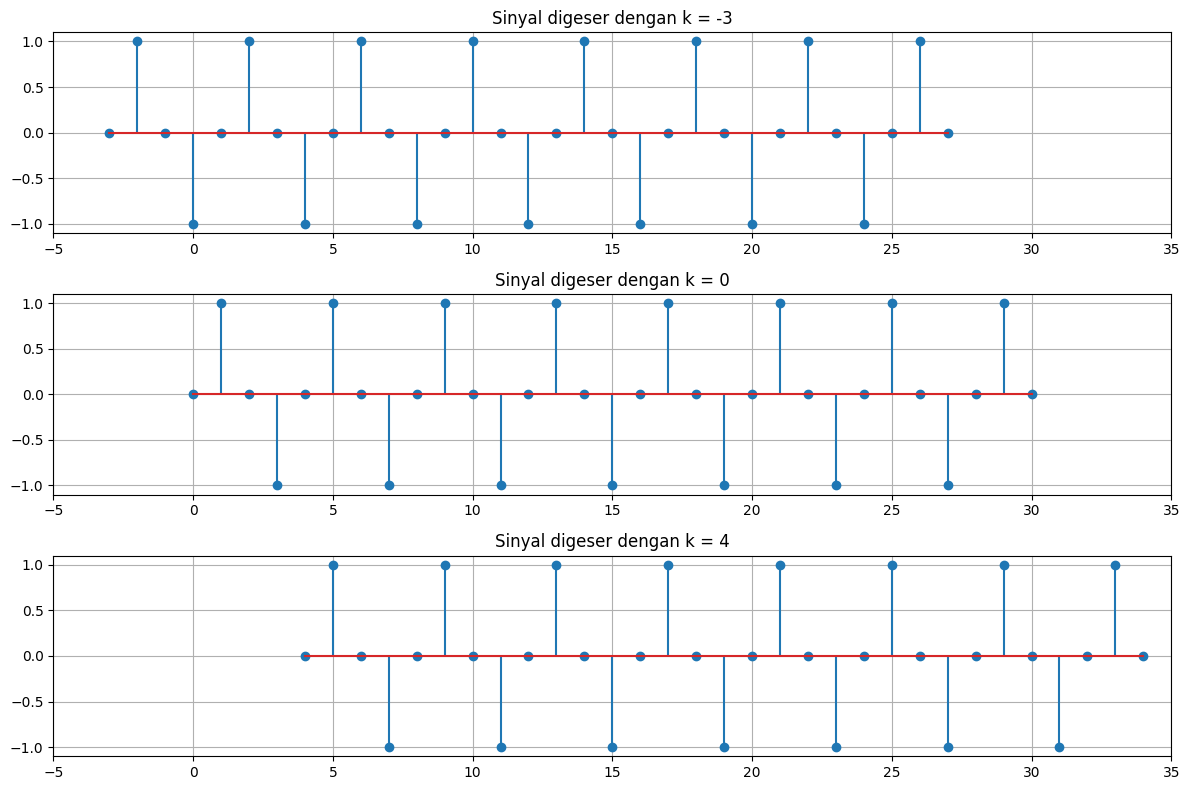

In [35]:
# Nilai k yang diminta: -3, 0, 4
k_values = [-3, 0, 4]

plt.figure(figsize=(12, 8))
for i, k in enumerate(k_values):
    plt.subplot(3, 1, i+1)
    # n - k untuk menggeser sumbu horizontal
    plt.stem(n + k, x1)
    plt.xlim(-5, 35)
    plt.title(f'Sinyal digeser dengan k = {k}')
    plt.grid(True)

plt.tight_layout()
plt.show()

**Analisis Penggeseran (Jawaban A.3):**
1. **k positif vs negatif:** Nilai k positif (k=4) menggeser sinyal ke kanan yang berarti sinyal mengalami *delay* atau keterlambatan. Nilai k negatif (k=-3) menggeser sinyal ke kiri yang berarti sinyal mendahului (lebih awal).
2. **Simulasi Delay:** Penggeseran memodelkan waktu tempuh sinyal dari pemancar ke penerima di dunia nyata (jeda waktu/delay).
3. **Pentingnya Time Alignment:** Penyelarasan waktu penting agar jika ada beberapa sinyal yang digabung, gelombangnya tidak saling bertabrakan atau saling membatalkan (*fase destruktif*).

## Bagian A.4: Operasi Amplifikasi Sinyal

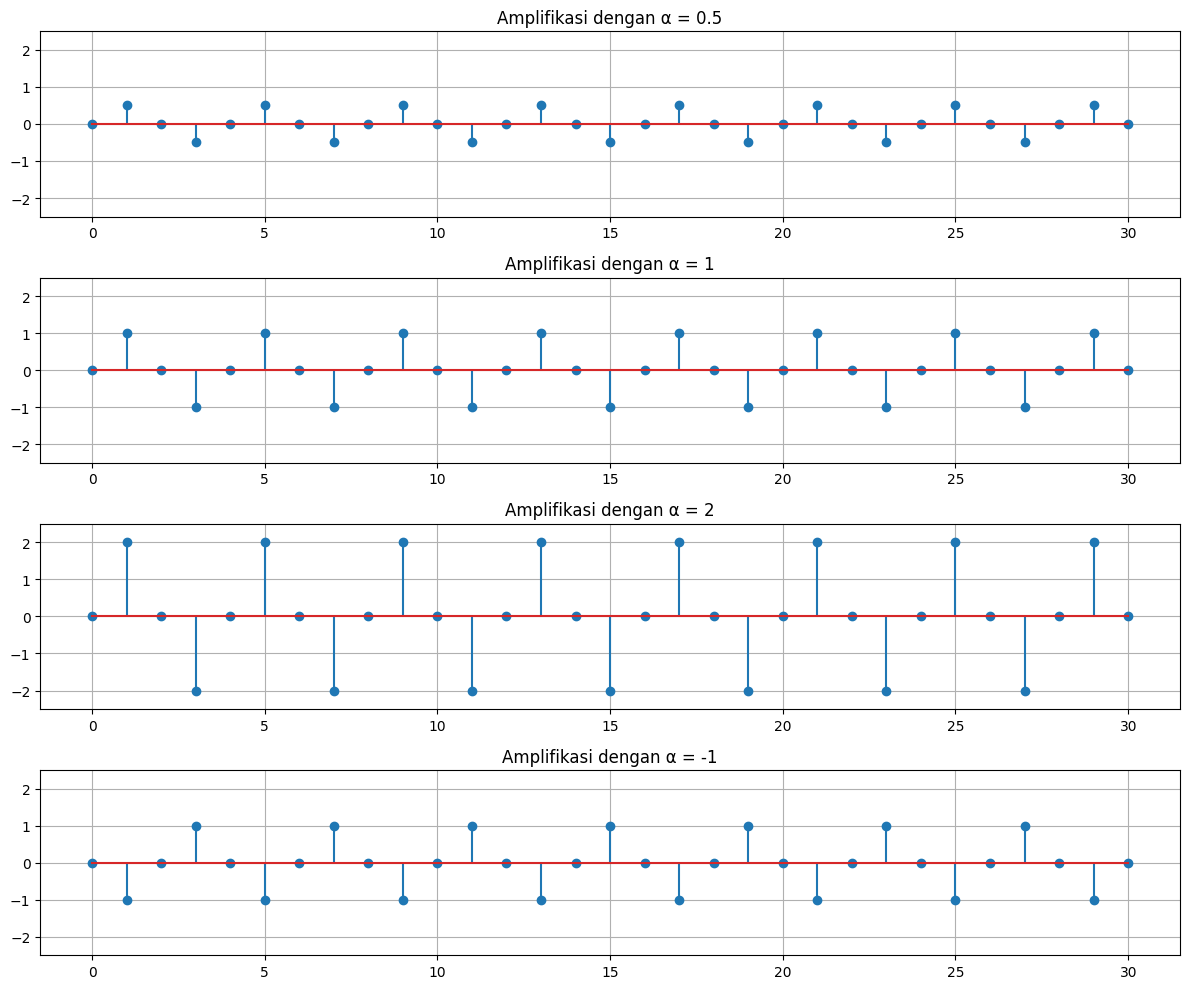

In [36]:
alpha_values = [0.5, 1, 2, -1]

plt.figure(figsize=(12, 10))
for i, a in enumerate(alpha_values):
    plt.subplot(4, 1, i+1)
    y_amp = a * x1
    plt.stem(n, y_amp)
    plt.ylim(-2.5, 2.5)
    plt.title(f'Amplifikasi dengan α = {a}')
    plt.grid(True)

plt.tight_layout()
plt.show()

**Analisis Amplifikasi (Jawaban A.4):**
1. **Jika α > 1:** Sinyal mengalami penguatan (amplitudo membesar).
2. **Jika 0 < α < 1:** Sinyal mengalami peredaman (amplitudo mengecil).
3. **Jika α negatif (-1):** Sinyal mengalami pembalikan fase (tercermin ke bawah). Sumbu positif menjadi negatif dan sebaliknya.
4. **Kaitan dengan Gain Audio:** Amplifikasi sama persis dengan memutar tombol *volume* atau *gain* pada speaker. Mengalikan angka berarti memperbesar atau memperkecil suara.

## Bagian B.1: Membaca Citra 2D

Ukuran Citra: (300, 400, 3) (Tinggi, Lebar, Saluran Warna)
Tipe Data Citra: uint8
Nilai Pixel Minimum: 0
Nilai Pixel Maksimum: 176


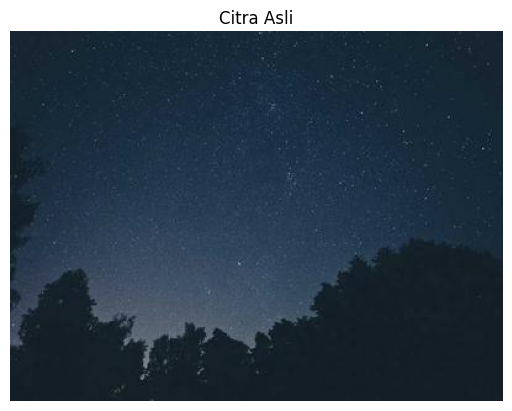

In [37]:
# Mendownload gambar contoh dari internet secara otomatis
urllib.request.urlretrieve("https://picsum.photos/400/300?random=1", "citra1.jpg")
urllib.request.urlretrieve("https://picsum.photos/400/300?random=2", "citra2.jpg")

# Membaca gambar menggunakan OpenCV
img1 = cv2.imread('citra1.jpg')
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB) # Ubah format warna ke standar RGB

# Menampilkan informasi gambar
print(f"Ukuran Citra: {img1.shape} (Tinggi, Lebar, Saluran Warna)")
print(f"Tipe Data Citra: {img1.dtype}")
print(f"Nilai Pixel Minimum: {np.min(img1)}")
print(f"Nilai Pixel Maksimum: {np.max(img1)}")

# Menampilkan gambar
plt.imshow(img1)
plt.title("Citra Asli")
plt.axis('off')
plt.show()

## Bagian B.2: Penjumlahan Citra

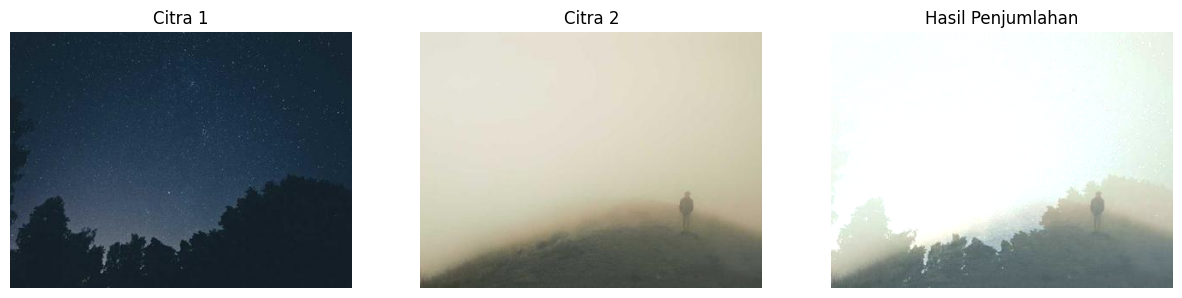

In [38]:
img2 = cv2.imread('citra2.jpg')
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# RESIZING: Memastikan ukurannya persis sama sebelum dijumlahkan
img2_resized = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

# Operasi Penjumlahan (cv2.add otomatis melakukan clipping agar tidak lewat dari 255)
img_jumlah = cv2.add(img1, img2_resized)

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img1); axes[0].set_title('Citra 1'); axes[0].axis('off')
axes[1].imshow(img2_resized); axes[1].set_title('Citra 2'); axes[1].axis('off')
axes[2].imshow(img_jumlah); axes[2].set_title('Hasil Penjumlahan'); axes[2].axis('off')
plt.show()

**Analisis Penjumlahan Citra (Jawaban B.2):**
1. **Mengapa ukuran harus sama?** Karena penjumlahan dilakukan secara piksel-ke-piksel (matriks matematika). Jika matriks beda ukuran, tidak bisa dijumlahkan.
2. **Jika melebihi nilai maksimal (255):** Jika nilai piksel lebih dari 255 dan tidak dibatasi, warnanya akan kembali dari 0 (overflow) membuat gambar berantakan (cacat warna).
3. **Clipping vs Normalisasi:** Clipping memotong batas angka menjadi 255 (gambar bisa terlalu putih menyilaukan di area terang), sedangkan normalisasi meratakan ulang semua nilai kembali ke rentang 0-255 sehingga detailnya tetap terjaga tapi kontras berubah.
4. **Aplikasi Nyata:** Digunakan untuk teknik *Image Blending* atau *Double Exposure* pada fotografi.

## Bagian B.3: Operasi Penggeseran Citra (Translasi)

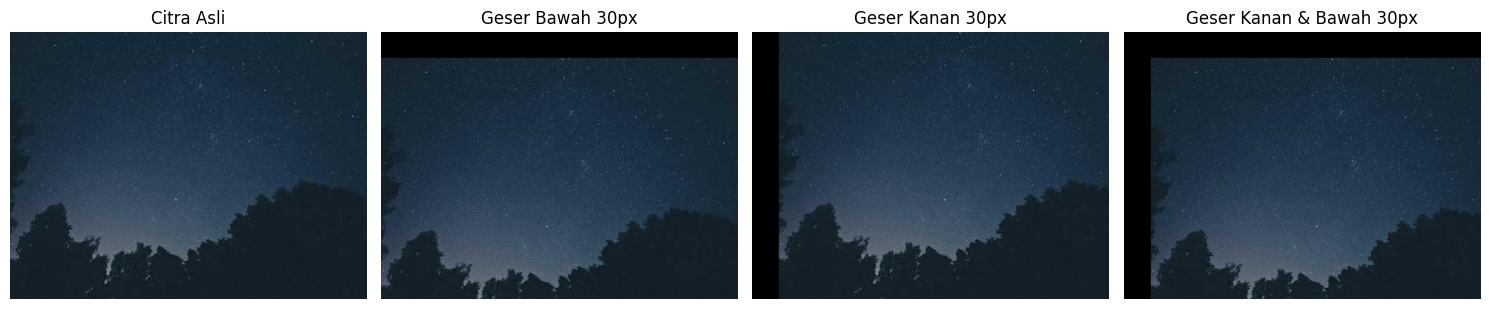

In [39]:
# Definisi pergeseran (Tinggi/Y, Lebar/X) = (∆i, ∆j)
# Di OpenCV pergeseran ditulis sebagai (∆j, ∆i) atau (X, Y)
shifts = [(0, 30), (30, 0), (30, 30)]
titles = ['Geser Bawah 30px', 'Geser Kanan 30px', 'Geser Kanan & Bawah 30px']

plt.figure(figsize=(15, 5))

# Plot gambar asli dulu
plt.subplot(1, 4, 1)
plt.imshow(img1)
plt.title('Citra Asli')
plt.axis('off')

baris, kolom = img1.shape[:2]

# Looping untuk 3 kombinasi pergeseran
for i, (dx, dy) in enumerate(shifts):
    # Membuat matriks translasi (penggeseran)
    M = np.float32([[1, 0, dx], [0, 1, dy]])
    # Menerapkan matriks ke gambar
    img_geser = cv2.warpAffine(img1, M, (kolom, baris))

    plt.subplot(1, 4, i+2)
    plt.imshow(img_geser)
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

**Analisis Penggeseran Citra (Jawaban B.3):**
1. **Efek posisi:** Objek dalam citra berpindah sejauh piksel yang ditentukan.
2. **Area kosong:** Muncul warna hitam (area kosong) di sisi yang ditinggalkan objek. Ini karena matriks tidak memiliki data untuk mengisi ruang kosong tersebut setelah gambar digeser (disebut *padding*).
3. **Translasi untuk Augmentasi:** Dalam *Machine Learning*, ini digunakan agar kecerdasan buatan (AI) mengenali objek tidak peduli apakah posisinya di tengah, pinggir, atau pojok gambar.
4. **Risiko penggeseran besar:** Jika digeser terlalu jauh, objek utama akan keluar dari batas layar dan terpotong secara permanen sehingga informasi penting hilang.

## Bagian B.4: Operasi Amplifikasi Citra

/tmp/ipykernel_3349/3271029937.py:15: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1, i].hist(img_amp.ravel(), 256, [0, 256], color='blue', alpha=0.7)


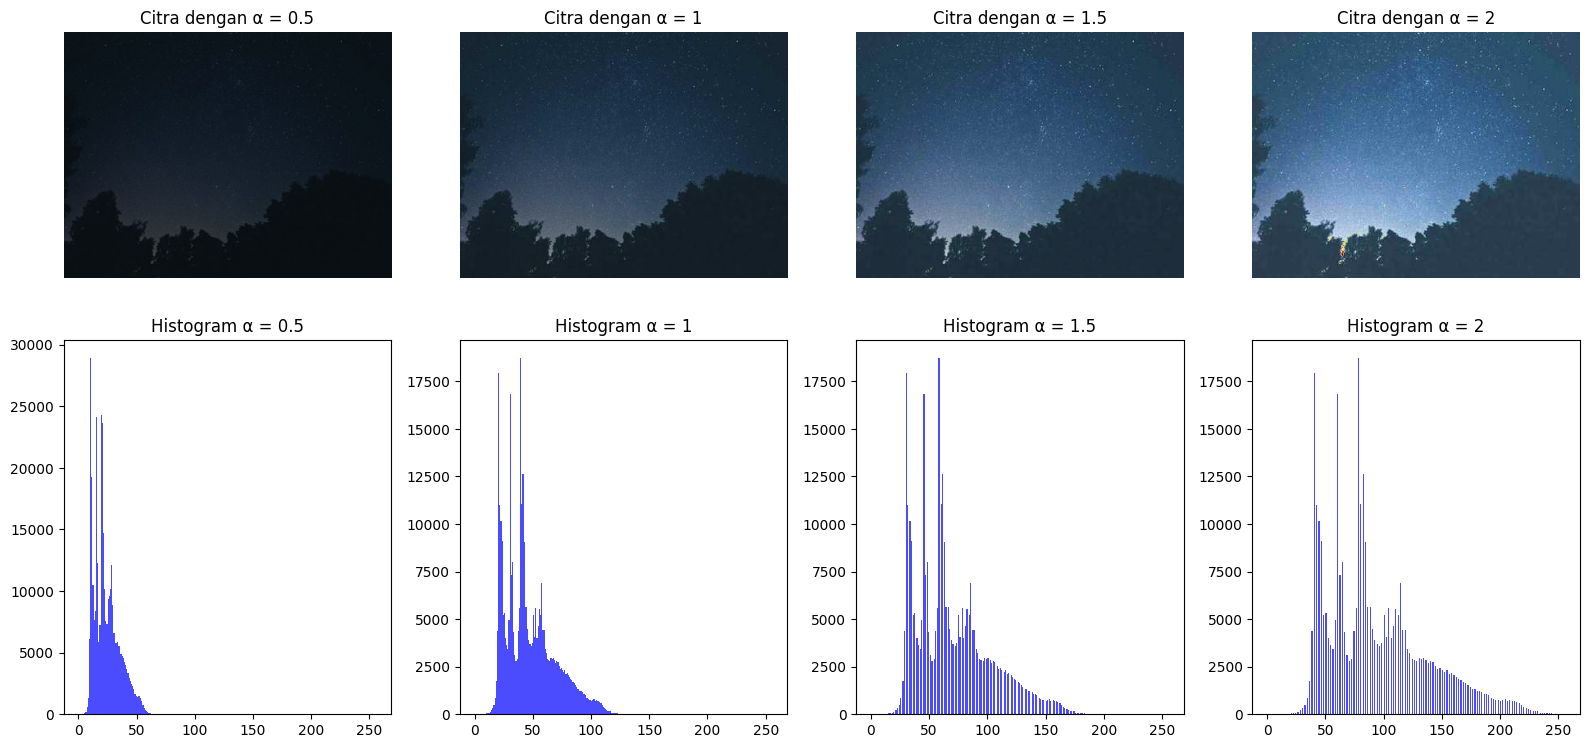

In [40]:
alphas_img = [0.5, 1, 1.5, 2]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, alpha in enumerate(alphas_img):
    # Mengalikan gambar dengan alpha. Gunakan np.clip agar nilai tidak lebih dari 255
    img_amp = np.clip(img1 * alpha, 0, 255).astype(np.uint8)

    # Plot Gambar
    axes[0, i].imshow(img_amp)
    axes[0, i].set_title(f'Citra dengan α = {alpha}')
    axes[0, i].axis('off')

    # Plot Histogram (Grafik sebaran warna)
    axes[1, i].hist(img_amp.ravel(), 256, [0, 256], color='blue', alpha=0.7)
    axes[1, i].set_title(f'Histogram α = {alpha}')

plt.tight_layout()
plt.show()

**Analisis Amplifikasi Citra (Jawaban B.4):**
1. **Efek α > 1:** Citra menjadi lebih terang (kecerahan naik) karena nilai setiap piksel dikalikan angka yang lebih besar dari 1. Histogram bergeser ke kanan (mendekati 255).
2. **Efek 0 < α < 1:** Citra menjadi lebih gelap karena nilai piksel mengecil. Histogram bergeser menumpuk ke kiri (mendekati angka 0/hitam).
3. **Kenapa nilai dibatasi (clipping)?** Layar monitor hanya bisa membaca warna dalam rentang 0 hingga 255 (format 8-bit). Jika tidak dibatasi, angka 256 akan kembali dibaca sebagai 0 (hitam), membuat warna gambar berantakan (efek overflow).

## Bagian C: Menguji Sistem Linier T1(x)=2x dan T2(x)=x^2

In [41]:
# Kita uji dengan array sederhana
x_test1 = np.array([1, 2, 3])
x_test2 = np.array([4, 5, 6])
alpha_test = 3

# Fungsi T1(x) = 2x
def T1(x): return 2 * x

# Fungsi T2(x) = x^2
def T2(x): return x ** 2

print("=== UJI T1(x) = 2x ===")
print(f"Homogenitas: T1(a*x) = {T1(alpha_test * x_test1)}, a*T1(x) = {alpha_test * T1(x_test1)}")
print(f"Additivitas: T1(x1+x2) = {T1(x_test1 + x_test2)}, T1(x1)+T1(x2) = {T1(x_test1) + T1(x_test2)}")
print("Kesimpulan T1: Linier (Nilai Kiri dan Kanan SAMA)\n")

print("=== UJI T2(x) = x^2 ===")
print(f"Homogenitas: T2(a*x) = {T2(alpha_test * x_test1)}, a*T2(x) = {alpha_test * T2(x_test1)}")
print(f"Additivitas: T2(x1+x2) = {T2(x_test1 + x_test2)}, T2(x1)+T2(x2) = {T2(x_test1) + T2(x_test2)}")
print("Kesimpulan T2: TIDAK Linier (Nilai Kiri dan Kanan BEDA)")

=== UJI T1(x) = 2x ===
Homogenitas: T1(a*x) = [ 6 12 18], a*T1(x) = [ 6 12 18]
Additivitas: T1(x1+x2) = [10 14 18], T1(x1)+T1(x2) = [10 14 18]
Kesimpulan T1: Linier (Nilai Kiri dan Kanan SAMA)

=== UJI T2(x) = x^2 ===
Homogenitas: T2(a*x) = [ 9 36 81], a*T2(x) = [ 3 12 27]
Additivitas: T2(x1+x2) = [25 49 81], T2(x1)+T2(x2) = [17 29 45]
Kesimpulan T2: TIDAK Linier (Nilai Kiri dan Kanan BEDA)


**Analisis Sistem Linier (Jawaban C.3):**
1. **Mengapa T1(x) = 2x linier?** Karena memenuhi syarat homogenitas dan additivitas. Jika input dinaikkan 3x lipat, outputnya pasti naik 3x lipat secara proporsional.
2. **Mengapa T2(x) = x^2 tidak linier?** Karena perpangkatan merusak proporsionalitas. Mengalikan input tidak akan menghasilkan kelipatan output yang sama, melainkan kuadratnya (melanggar homogenitas dan additivitas).
3. **Pentingnya Sistem Linier:** Sistem linier memungkinkan kita mengurai sinyal yang sangat rumit menjadi sinyal-sinyal sederhana, memprosesnya satu per satu, lalu menjumlahkannya kembali (Konsep Superposisi).

## Bagian D: Analisis HOTS

**D.1 Analisis Konseptual:**
1. Penjumlahan mewakili aturan "additivitas", dan amplifikasi mewakili "homogenitas". Gabungan dari dua aturan ini menciptakan hukum fundamental bernama Superposisi.
2. Tidak semua operasi linier karena ada pengolahan yang mendistorsi sinyal, seperti pembatasan batas maksimum (clipping) atau perpangkatan seperti uji T2 sebelumnya.

**D.2 Analisis Aplikasi Nyata (Studi Kasus: Audio Mixing):**
1. **Masalah:** Ingin menyatukan suara rekaman vokal dan musik latar.
2. **Operasi yang dipakai:** Penjumlahan sinyal (untuk menggabungkan) dan Amplifikasi (untuk mengatur volume tiap instrumen).
3. **Relevansi:** Suara di dunia nyata bersifat superposisi (gelombang menumpuk). Secara digital, kita mereplikasinya dengan menjumlahkan angkanya.
4. **Sifat sistem:** Linier.
5. **Kelebihan & Keterbatasan:** Kelebihannya adalah komputasi ringan. Keterbatasannya adalah rentan mengalami suara pecah (clipping) jika total penjumlahan suara melewati batas memori.

**D.3 Skenario Keputusan:**
1. **Skenario 1 (Image Blending ukuran beda):** Harus melakukan operasi Resizing (menyamakan resolusi) terlebih dahulu. Alasannya, penjumlahan citra adalah penjumlahan matriks matematika; aturan matriks mengharuskan ukuran kolom dan baris sama persis.
2. **Skenario 2 (Audio kecil):** Harus dilakukan Amplifikasi (dengan α > 1). Risikonya, jika α terlalu besar, puncak gelombang suara akan terpotong paksa di batas maksimum sistem, memicu distorsi/suara berisik.
3. **Skenario 3 (Deteksi objek variasi posisi):** Penggeseran menciptakan salinan data (gambar) di mana objek berada di posisi baru. Ini "memaksa" sistem AI belajar mengenali bentuk aslinya, bukan sekadar menghafal lokasinya di tengah.
4. **Skenario 4 (Urutan filter ditukar hasil beda):** Sistem tersebut BUKAN sistem linier. Menurut aturan dasar sistem linier, operasi secara berurutan (cascade) bersifat komutatif, yang berarti menukar urutan proses seharusnya tidak akan mengubah output akhirnya.

---
**REFLEKSI PRIBADI**
(Catatan untuk Mahasiswa: Silakan isi jawaban ini sesuai yang Anda rasakan selama mencoba kode-kode di atas)
1. Operasi paling mudah dipahami: Operasi Amplifikasi, karena logikanya hanya mengalikan data dengan sebuah angka (volume/brightness naik turun).
2. Operasi paling sulit: Penjumlahan Citra, karena harus memperhatikan ukuran resolusi yang sama dan memikirkan aturan batasan pixel 255.
3. Beda utama 1D dan 2D: Sinyal 1D hanya memiliki satu sumbu panjang (waktu), sementara 2D melibatkan ruang matriks berupa koordinat sumbu X dan Y.
4. Hal baru sistem linier: Ternyata konsep matematis (homogenitas) memiliki implikasi langsung di dunia nyata, contohnya menentukan apakah sebuah filter gambar bisa diprediksi hasilnya atau tidak.
5. Paling penting di aplikasi nyata: Memahami batas maksimum data (seperti perlunya Clipping pada gambar atau pembatasan volume pada audio) agar sistem tidak mengalami kerusakan output atau error.